In [ ]:
import sys

sys.path.append("../src")

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from energy_load_forecast.evaluation import evaluate
from energy_load_forecast.features import add_all_features
from energy_load_forecast.ingestion import load_and_resample
from energy_load_forecast.models.lightgbm_model import (
    feature_importance,
    train_lightgbm,
)
from energy_load_forecast.models.lightgbm_model import predict as lgbm_predict
from energy_load_forecast.preprocessing import (
    add_calendar_features,
    chronological_split,
    clean_tail,
)

series = load_and_resample(Path("../data/raw/entsoe/load_RO_2026-09-13_2026-09-20.csv"))
series_clean = clean_tail(series)
df = add_calendar_features(series_clean.to_frame())
df = add_all_features(df, lags=[1, 24, 168], windows=[3, 24])

train_df, val_df, test_df = chronological_split(df, train_end="2026-09-16", val_end="2026-09-18")
X_train, y_train = train_df.drop(columns=["load_mw"]), train_df["load_mw"]
X_test, y_test = test_df.drop(columns=["load_mw"]), test_df["load_mw"]

model = train_lightgbm(X_train, y_train)
y_test_pred = lgbm_predict(model, X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Test metrics:", evaluate(y_test, y_test_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 117
[LightGBM] [Info] Number of data points in the train set: 72, number of used features: 7
[LightGBM] [Info] Start training from score 5141.819444
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

Feature importances:
 load_mw_lag24               57
load_mw_rolling_mean_24h    35
hour_local                  33
load_mw_lag1                18
load_mw_rolling_mean_3h     14
month_local                  0
is_weekend_local             0
day_of_week_local            0
load_mw_lag168               0
dtype: int32


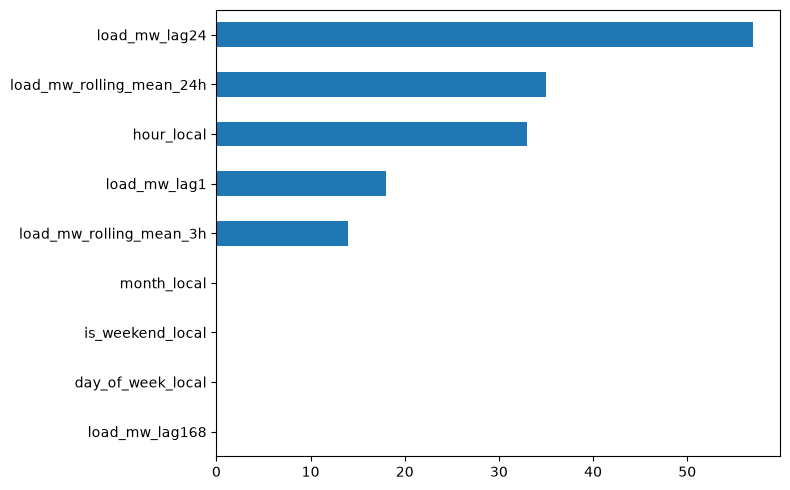

In [ ]:
importances = feature_importance(model, list(X_train.columns))
importances.plot(kind="barh", figsize=(8, 5))
plt.gca().invert_yaxis()
plt.tight_layout()
print("Feature importances:\n", importances)

                            actual    predicted
timestamp_utc                                  
2026-09-18 00:00:00+00:00  4867.50  5325.947752
2026-09-18 01:00:00+00:00  4934.25  5325.947752
2026-09-18 02:00:00+00:00  5111.50  5325.947752
2026-09-18 03:00:00+00:00  5459.00  5682.933074
2026-09-18 04:00:00+00:00  5893.25  6015.635694
2026-09-18 05:00:00+00:00  5953.75  5934.860786
2026-09-18 06:00:00+00:00  5721.25  5832.675830
2026-09-18 07:00:00+00:00  5247.25  5251.980258
2026-09-18 08:00:00+00:00  4880.75  4898.223192
2026-09-18 09:00:00+00:00  4876.50  4881.225593
2026-09-18 10:00:00+00:00  5044.25  4962.148412
2026-09-18 11:00:00+00:00  4734.00  4884.240350
2026-09-18 12:00:00+00:00  4789.00  4711.211675
2026-09-18 13:00:00+00:00  5192.00  4851.516483
2026-09-18 14:00:00+00:00  5784.25  5840.444132
2026-09-18 15:00:00+00:00  6223.75  6152.580341
2026-09-18 16:00:00+00:00  6583.00  6166.040491
2026-09-18 17:00:00+00:00  6720.50  6166.040491
2026-09-18 18:00:00+00:00  6396.25  6166

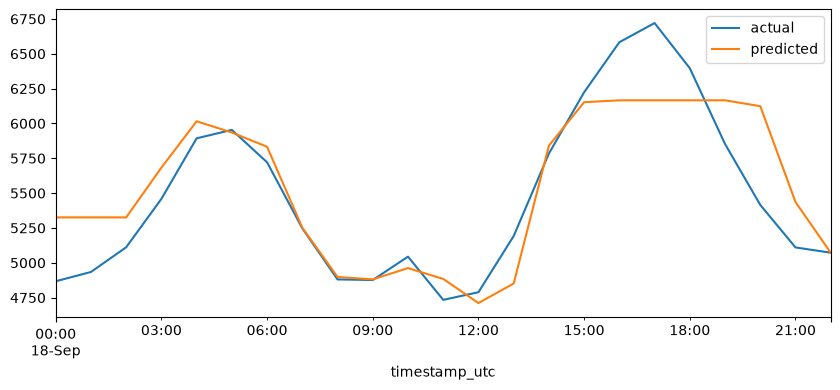

In [ ]:
comparison_df = pd.DataFrame({"actual": y_test, "predicted": y_test_pred})
comparison_df.plot(figsize=(10, 4))
print(comparison_df)

In [ ]:
residuals = y_test - y_test_pred
residuals.name = "residual"
print("Residuals:\n", residuals)
print("Mean residual:", residuals.mean())
print("Std residual:", residuals.std())

bias_threshold = 0.05 * y_test.mean()
if abs(residuals.mean()) > bias_threshold:
    print(f"WARNING: Mean residual ({residuals.mean():.2f}) exceeds 5% of mean actual ({bias_threshold:.2f}). Model has systematic bias.")
else:
    print(f"Mean residual within 5% of mean actual ({bias_threshold:.2f}). No systematic bias detected.")

Residuals:
 timestamp_utc
2026-09-18 00:00:00+00:00   -458.447752
2026-09-18 01:00:00+00:00   -391.697752
2026-09-18 02:00:00+00:00   -214.447752
2026-09-18 03:00:00+00:00   -223.933074
2026-09-18 04:00:00+00:00   -122.385694
2026-09-18 05:00:00+00:00     18.889214
2026-09-18 06:00:00+00:00   -111.425830
2026-09-18 07:00:00+00:00     -4.730258
2026-09-18 08:00:00+00:00    -17.473192
2026-09-18 09:00:00+00:00     -4.725593
2026-09-18 10:00:00+00:00     82.101588
2026-09-18 11:00:00+00:00   -150.240350
2026-09-18 12:00:00+00:00     77.788325
2026-09-18 13:00:00+00:00    340.483517
2026-09-18 14:00:00+00:00    -56.194132
2026-09-18 15:00:00+00:00     71.169659
2026-09-18 16:00:00+00:00    416.959509
2026-09-18 17:00:00+00:00    554.459509
2026-09-18 18:00:00+00:00    230.209509
2026-09-18 19:00:00+00:00   -313.540491
2026-09-18 20:00:00+00:00   -708.435565
2026-09-18 21:00:00+00:00   -326.114895
2026-09-18 22:00:00+00:00      0.401446
Freq: h, Name: residual, dtype: float64
Mean residual:

Residual histogram plotted


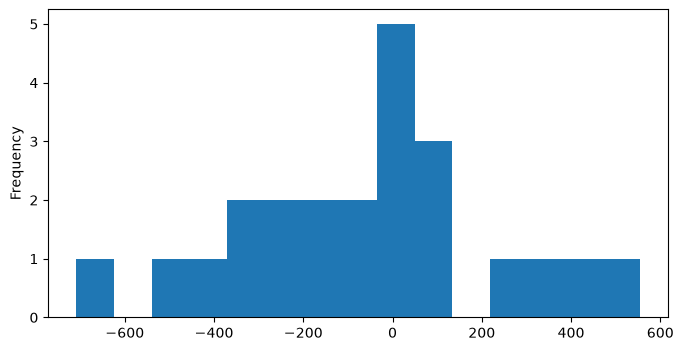

In [ ]:
residuals.plot(kind="hist", bins=15, figsize=(8, 4))
print("Residual histogram plotted")

Residuals over time plotted


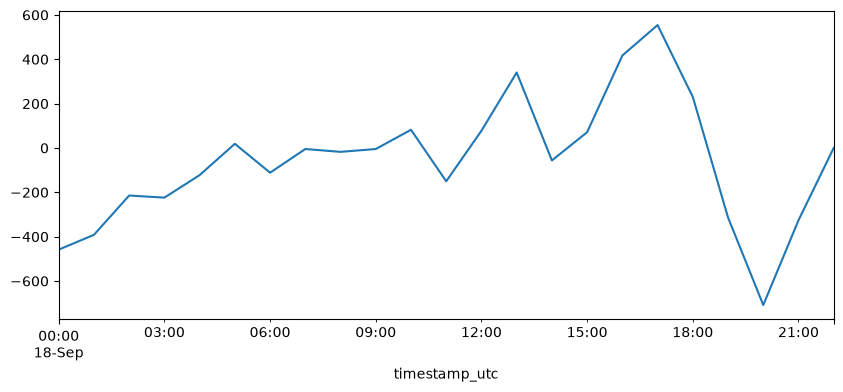

In [ ]:
residuals.plot(figsize=(10, 4))
print("Residuals over time plotted")

Mean absolute residual by hour_local:
 hour_local
23    708.435565
20    554.459509
3     458.447752
19    416.959509
4     391.697752
16    340.483517
0     326.114895
22    313.540491
21    230.209509
6     223.933074
5     214.447752
14    150.240350
7     122.385694
9     111.425830
13     82.101588
15     77.788325
18     71.169659
17     56.194132
8      18.889214
11     17.473192
10      4.730258
12      4.725593
1       0.401446
Name: residual, dtype: float64


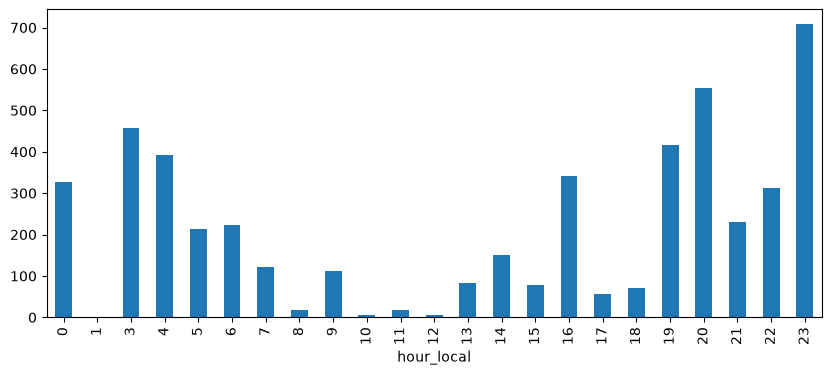

In [ ]:
residuals_with_hour = pd.DataFrame({
    "residual": residuals,
    "hour_local": test_df["hour_local"],
})
abs_residual_by_hour = residuals_with_hour.groupby("hour_local")["residual"].apply(lambda x: x.abs().mean())
abs_residual_by_hour.plot(kind="bar", figsize=(10, 4))
print("Mean absolute residual by hour_local:\n", abs_residual_by_hour.sort_values(ascending=False))

In [ ]:
abs_residuals = residuals.abs().sort_values(ascending=False)
top5_index = abs_residuals.head(5).index
top5 = test_df.loc[top5_index, ["hour_local", "is_weekend_local"]].assign(
    actual=y_test.loc[top5_index],
    predicted=y_test_pred.loc[top5_index],
    abs_error=abs_residuals.head(5),
)
print("Top 5 largest errors:\n", top5)

Top 5 largest errors:
                            hour_local  is_weekend_local   actual    predicted  \
timestamp_utc                                                                   
2026-09-18 20:00:00+00:00          23             False  5415.50  6123.935565   
2026-09-18 17:00:00+00:00          20             False  6720.50  6166.040491   
2026-09-18 00:00:00+00:00           3             False  4867.50  5325.947752   
2026-09-18 16:00:00+00:00          19             False  6583.00  6166.040491   
2026-09-18 01:00:00+00:00           4             False  4934.25  5325.947752   

                            abs_error  
timestamp_utc                          
2026-09-18 20:00:00+00:00  708.435565  
2026-09-18 17:00:00+00:00  554.459509  
2026-09-18 00:00:00+00:00  458.447752  
2026-09-18 16:00:00+00:00  416.959509  
2026-09-18 01:00:00+00:00  391.697752  
